In [807]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import json
import ast
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from scipy import stats
from sklearn.metrics import mean_squared_error,mean_absolute_error
import plotly.express as px
import plotly.figure_factory as ff
import statsmodels.api as sm
from scipy.stats import shapiro

In [2]:
# extracting dictionaray from string
def extract_dict(series):
    return(series.astype(str).apply(lambda x : ast.literal_eval(x)))

In [604]:
# outlier removal function
def remove_outliers(df):
    new_df=pd.DataFrame()
    removed_df=pd.DataFrame()
    for key,subdf in df.groupby('new_locality'):
        subdf['z_score']=stats.zscore(np.log(subdf.price_per_sqft))
        ## extracting removed and filtered df of particular locality
        subdf_filtered=subdf[subdf.z_score.between(-2,2)]
        subdf_removed=subdf[~(subdf.z_score.between(-2,2))]
        ## adding it to final data frames
        new_df=pd.concat([subdf_filtered,new_df],ignore_index=True)
        removed_df=pd.concat([subdf_removed,removed_df],ignore_index=True)
    
    return(new_df,removed_df)

In [3]:
z=glob.glob('C:/Users/Admin/Desktop/hyderabad.csv')

In [4]:
data=pd.DataFrame()

In [5]:
hyderabad=pd.read_csv(z[0])

In [6]:
hyderabad.columns

Index(['SPID', 'PROP_ID', 'PREFERENCE', 'DESCRIPTION', 'PROPERTY_TYPE', 'CITY',
       'TRANSACT_TYPE', 'OWNTYPE', 'BEDROOM_NUM', 'PRICE_PER_UNIT_AREA',
       'FURNISH', 'FACING', 'AGE', 'TOTAL_FLOOR', 'FEATURES', 'REGISTER_DATE',
       'POSTING_DATE', 'UPDATE_DATE', 'CLASS', 'RES_COM', 'PROP_NAME',
       'PROPERTY_NUMBER', 'MIN_PRICE', 'MAX_PRICE', 'PRICE_SQFT', 'PROJ_ID',
       'BUILDING_ID', 'VERIFIED', 'MAP_DETAILS', 'MIN_AREA_SQFT',
       'MAX_AREA_SQFT', 'AMENITIES', 'ALT_TAG', 'PRODUCT_TYPE', 'TOP_USPS',
       'EXPIRY_DATE', 'PROPERTY_TYPE__U', 'AREA', 'SECONDARY_AREA', 'PRICE',
       'PROP_HEADING', 'VALUE_LABEL', 'CLASS_HEADING', 'CLASS_LABEL',
       'REGISTER_DATE__U', 'REGISTERED_DAYS', 'PRIMARY_TAGS', 'SECONDARY_TAGS',
       'TOTAL_LANDMARK_COUNT', 'FORMATTED_LANDMARK_DETAILS', 'SOCIETY_NAME',
       'BUILDING_NAME', 'location', 'BALCONY_NUM', 'FLOOR_NUM'],
      dtype='object')

In [221]:
drop_index=hyderabad[~((hyderabad.MAX_PRICE-hyderabad.MIN_PRICE)==0)].index

In [310]:
hyderabad[(hyderabad.MAX_PRICE/hyderabad.MAX_AREA_SQFT)>200000].shape

(404, 55)

In [223]:
hyderabad=hyderabad.drop(index=drop_index)

In [224]:
hyderabad=hyderabad.reset_index(drop=True)

In [236]:
drop_index=hyderabad[((hyderabad.MAX_AREA_SQFT-hyderabad.MIN_AREA_SQFT)>1)].index

In [240]:
hyderabad=hyderabad.drop(index=drop_index)
hyderabad=hyderabad.reset_index(drop=True)

In [241]:
hyderabad.shape

(9020, 55)

In [321]:
# extracting only number values from area column (removing sqft_part)
hyderabad['AREA_UNITS']=hyderabad['AREA'].apply(lambda x : x.split(' ')[0])

In [328]:
index=hyderabad[hyderabad.AREA_UNITS.str.contains('-')].index
# assigning average values to area which are given as group
values=hyderabad.iloc[index].AREA_UNITS.apply(lambda x : x.split('-')).apply(lambda y : (int(y[1])+int(y[0]))/2)

In [330]:
hyderabad.at[index,'AREA_UNITS']=values

In [339]:
drop_index=hyderabad[(hyderabad.MAX_PRICE/hyderabad.AREA_UNITS.astype('int64'))>100000].index

In [340]:
hyderabad=hyderabad.drop(index=drop_index)

In [341]:
hyderabad=hyderabad.reset_index(drop=True)

In [342]:
hyderabad.shape

(8947, 56)

In [377]:
hyderabad=hyderabad[hyderabad.PREFERENCE=='S']

In [378]:
hyderabad=hyderabad[(hyderabad.MAX_PRICE/hyderabad.AREA_UNITS.astype('int64'))<20000]

In [379]:
hyderabad.shape

(7080, 56)

In [343]:
# selecting SPID for dropping
# selecting Description for drop because information is extracted and is put in other columns
# Dropping Trandact_type bcz no information given on encoding
# dropping registered_date , posting_date , update_date bcz dates are of website registry dates
# dropping res_Com bcz it has only one value i.e 'R'
# dropping property_number bcz no encoding info given
# dropping Price_per_unit_Area , min_area_sqft , max_area_sqft bcz area,price already specified in different columns
# dropping  Alt_tag (uncessary)
# droppinng proj_Id
# dropping expiry_date ,secondary_area , prop_heading  (website information)
# dropping column owntype (duplicate column with different name i.e 'value_label')
# dropping class_heading 
# dropping Registered_date__u , Registered_days 
# dropping primary_tags, secondary_tags (not many values and so many nulls)
# dropping formatted_landmark_details

In [385]:
columns=['SPID','DESCRIPTION','TRANSACT_TYPE','REGISTER_DATE','POSTING_DATE','UPDATE_DATE','RES_COM',
         'PROPERTY_NUMBER','PRICE_PER_UNIT_AREA','PROJ_ID','AREA','MIN_AREA_SQFT','MAX_PRICE','PRICE',
         'ALT_TAG','EXPIRY_DATE','SECONDARY_AREA','PROP_HEADING','OWNTYPE','CLASS_HEADING','PRICE_SQFT',
         'CLASS_LABEL','REGISTER_DATE__U','REGISTERED_DAYS','PRIMARY_TAGS','SECONDARY_TAGS',
         'MAX_AREA_SQFT','FORMATTED_LANDMARK_DETAILS',]

In [386]:
#dropping columns which are not neccesary for prediction
data_hyd=hyderabad.drop(columns=columns)

In [387]:
data_hyd.rename(columns=str.lower,inplace=True)

In [388]:
data_hyd.columns

Index(['prop_id', 'preference', 'property_type', 'city', 'bedroom_num',
       'furnish', 'facing', 'age', 'total_floor', 'features', 'class',
       'prop_name', 'min_price', 'building_id', 'verified', 'map_details',
       'amenities', 'product_type', 'top_usps', 'property_type__u',
       'value_label', 'total_landmark_count', 'society_name', 'building_name',
       'location', 'balcony_num', 'floor_num', 'area_units'],
      dtype='object')

In [389]:
data_hyd.rename(columns={'min_price':'price','area_units':'area'},inplace=True)

In [393]:
data_hyd.area=data_hyd.area.astype('int64')

In [394]:
data_hyd.dtypes

prop_id                  object
preference               object
property_type            object
city                     object
bedroom_num             float64
furnish                   int64
facing                    int64
age                       int64
total_floor             float64
features                 object
class                    object
prop_name                object
price                     int64
building_id               int64
verified                 object
map_details              object
amenities                object
product_type             object
top_usps                 object
property_type__u          int64
value_label              object
total_landmark_count    float64
society_name             object
building_name            object
location                 object
balcony_num             float64
floor_num                object
area                      int64
dtype: object

In [396]:
data_hyd.select_dtypes(include=['float64','int64']).describe()

,bedroom_num,furnish,facing,age,total_floor,price,building_id,property_type__u,total_landmark_count,balcony_num,area
count,4468.000000,7080.000000,7080.000000,7080.000000,6524.000000,7.080000e+03,7.080000e+03,7080.000000,5540.000000,4368.000000,7.080000e+03
mean,2.935765,1.343503,3.059605,2.555791,9.703403,1.595075e+07,1.952795e+05,2.009322,25.362094,1.743132,8.069730e+03
std,0.980509,1.302556,1.499675,2.505368,10.687720,4.489544e+07,3.724095e+05,2.533387,19.387999,0.821315,1.392799e+05
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000,1.000000e+02
25%,2.000000,0.000000,3.000000,0.000000,3.000000,4.600000e+06,0.000000e+00,1.000000,9.000000,1.000000,1.350000e+03
50%,3.000000,2.000000,3.000000,1.000000,5.000000,8.811000e+06,0.000000e+00,2.000000,15.000000,2.000000,1.691000e+03
75%,3.000000,2.000000,4.000000,5.000000,12.000000,1.700000e+07,1.081955e+05,3.000000,49.000000,2.000000,2.250000e+03
max,20.000000,4.000000,8.000000,6.000000,56.000000,2.147484e+09,1.125151e+06,90.000000,50.000000,4.000000,7.840800e+06


###### changes

In [14]:
# extracting only number values from area column (removing sqft_part)
data_hyd['area_units']=data_hyd['area'].apply(lambda x : x.split(' ')[0])

In [15]:
index=data_hyd[data_hyd.area_units.str.contains('-')].index
# assigning average values to area which are given as group
values=data_hyd.iloc[index].area_units.apply(lambda x : x.split('-')).apply(lambda y : (int(y[1])+int(y[0]))/2)

In [16]:
data_hyd.at[index,'area_units']=values

In [17]:
# calculated price per prices_per_sqft
data_hyd['price_cal']=data_hyd['area_units'].astype('float')*data_hyd['price_sqft'].astype('float')

In [18]:
# extracting actual price by averaging min and max price
data_hyd['price_value']=(data_hyd.max_price+data_hyd.min_price)/2

##### changed

In [397]:
data_hyd.columns

Index(['prop_id', 'preference', 'property_type', 'city', 'bedroom_num',
       'furnish', 'facing', 'age', 'total_floor', 'features', 'class',
       'prop_name', 'price', 'building_id', 'verified', 'map_details',
       'amenities', 'product_type', 'top_usps', 'property_type__u',
       'value_label', 'total_landmark_count', 'society_name', 'building_name',
       'location', 'balcony_num', 'floor_num', 'area'],
      dtype='object')

In [398]:
# extracting feature and amenities count for model
data_hyd['feature_count']=data_hyd.features.apply(lambda x : x.count(','))
data_hyd['amenities_count']=data_hyd.amenities.str.count(',')

In [399]:
# extracting locality name from location column for eda
data_hyd['locality']=extract_dict(data_hyd.location).apply(lambda x : x['LOCALITY_NAME'])

In [400]:
# dropping columns which has no price specified
data=data_hyd.drop(data_hyd[(data_hyd.price==0)].index)

In [401]:
data.shape

(7059, 31)

In [402]:
# taking only sales value and removing paying_guest and rent for better predictions

In [406]:
data.columns

Index(['prop_id', 'preference', 'property_type', 'city', 'bedroom_num',
       'furnish', 'facing', 'age', 'total_floor', 'features', 'class',
       'prop_name', 'price', 'building_id', 'verified', 'map_details',
       'amenities', 'product_type', 'top_usps', 'property_type__u',
       'value_label', 'total_landmark_count', 'society_name', 'building_name',
       'location', 'balcony_num', 'floor_num', 'area', 'feature_count',
       'amenities_count', 'locality'],
      dtype='object')

In [407]:
# data for ml
req_data=data.drop(columns=['prop_id','features','prop_name','verified','map_details',
                            'amenities','product_type','property_type__u',
                            'society_name','building_name','location'
                            ])

In [410]:
req_data.columns

Index(['preference', 'property_type', 'city', 'bedroom_num', 'furnish',
       'facing', 'age', 'total_floor', 'class', 'price', 'building_id',
       'top_usps', 'value_label', 'total_landmark_count', 'balcony_num',
       'floor_num', 'area', 'feature_count', 'amenities_count', 'locality'],
      dtype='object')

In [287]:
req_data.shape

(8999, 20)

In [412]:
req_data.dtypes

preference               object
property_type            object
city                     object
bedroom_num             float64
furnish                   int64
facing                    int64
age                       int64
total_floor             float64
class                    object
price                     int64
building_id               int64
top_usps                 object
value_label              object
total_landmark_count    float64
balcony_num             float64
floor_num                object
area                      int64
feature_count             int64
amenities_count         float64
locality                 object
dtype: object

In [413]:
req_data.isnull().sum()

preference                 0
property_type              0
city                       0
bedroom_num             2608
furnish                    0
facing                     0
age                        0
total_floor              552
class                      0
price                      0
building_id                0
top_usps                2673
value_label                0
total_landmark_count    1539
balcony_num             2696
floor_num               3748
area                       0
feature_count              0
amenities_count          752
locality                   0
dtype: int64

In [414]:
#dropping columns floor_num bcz of no replacement value

req_data.drop(columns=['floor_num'],inplace=True)
req_data=req_data.reset_index(drop=True)

In [415]:
#req_data.area=req_data.area.astype('float')

In [416]:
z=req_data[['bedroom_num','area']].value_counts().reset_index()

In [417]:
# extracting lookup for filling in the bedroom_num values
bed=z[z[0]>10].groupby('bedroom_num').area.mean().round().reset_index() # mean values of area for number of bathrooms
bed=bed.append({'bedroom_num':1.0,'area':100.0},ignore_index=True)
bed=bed.sort_values('bedroom_num').reset_index()
bed=bed.drop(columns=['index'])
bed

,bedroom_num,area
0,1.0,100.0
1,2.0,1225.0
2,3.0,1951.0
3,4.0,2958.0
4,5.0,5000.0
5,6.0,7500.0


In [420]:
req_data.area=req_data.area.astype('float64')

In [421]:
# creating values to be filled in at place of na 
g=pd.merge_asof(req_data[req_data.bedroom_num.isnull()].reset_index().sort_values('area'),bed,on='area')
g=g.sort_values('index')

In [422]:
index=req_data[req_data.bedroom_num.isnull()].index
values=g['bedroom_num_y']

In [423]:
req_data.loc[req_data.bedroom_num.isnull(),'bedroom_num']=values.values

In [424]:
print(req_data.bedroom_num.isnull().sum())
req_data.bedroom_num.fillna(1,inplace=True)

0


In [425]:
req_data.bedroom_num.isnull().sum()

0

In [426]:
req_data.drop(columns=['total_floor'],inplace=True)

In [427]:
req_data.amenities_count.fillna(0,inplace=True)
req_data.balcony_num.fillna(0,inplace=True)
req_data.total_landmark_count.fillna(0,inplace=True)

In [428]:
req_data.drop(columns='top_usps',inplace=True)

In [429]:
req_data.value_label.fillna('NO',inplace=True)

In [430]:
req_data.isnull().sum()

preference              0
property_type           0
city                    0
bedroom_num             0
furnish                 0
facing                  0
age                     0
class                   0
price                   0
building_id             0
value_label             0
total_landmark_count    0
balcony_num             0
area                    0
feature_count           0
amenities_count         0
locality                0
dtype: int64

In [431]:
req_data.drop(columns='building_id',inplace=True)

In [650]:
model_data=req_data.copy()

In [651]:
direction={0:'Unknown',1:'North',2:'South',3:'East',4:'West',5:'North_East',6:'North_West',7:'South-East',8:'South_west'}
furnish={0:'unknown',1:'furnished',2:'unfurnished',4:'semi-furnished'}

In [652]:
model_data['facing']=model_data.facing.map(direction)

In [653]:
model_data['furnish']=model_data.furnish.map(furnish)

In [654]:
model_data.isnull().any().sum()

0

In [655]:
model_data.columns

Index(['preference', 'property_type', 'city', 'bedroom_num', 'furnish',
       'facing', 'age', 'class', 'price', 'value_label',
       'total_landmark_count', 'balcony_num', 'area', 'feature_count',
       'amenities_count', 'locality'],
      dtype='object')

In [656]:
model_data.dtypes

preference               object
property_type            object
city                     object
bedroom_num             float64
furnish                  object
facing                   object
age                       int64
class                    object
price                     int64
value_label              object
total_landmark_count    float64
balcony_num             float64
area                    float64
feature_count             int64
amenities_count         float64
locality                 object
dtype: object

In [657]:
model_data.drop(columns='preference',inplace=True)

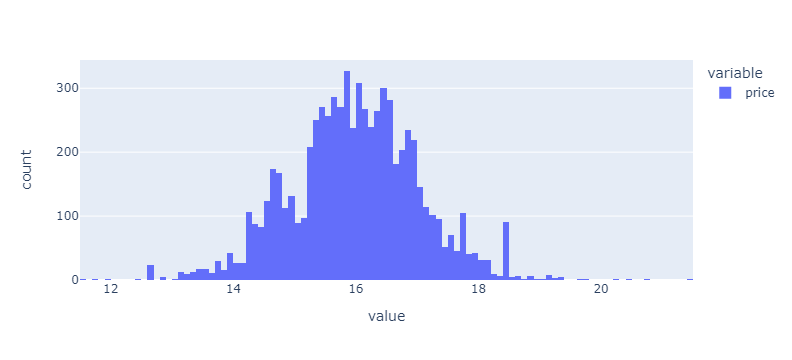

In [658]:
px.histogram(np.log(model_data.price))

E:\Anaconda\lib\site-packages\statsmodels\graphics\gofplots.py:993: UserWarning:

marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.



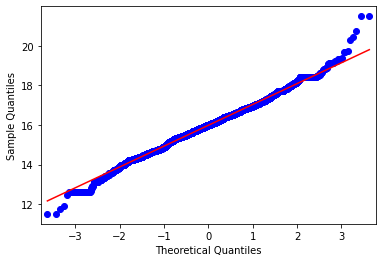

In [659]:
sm.qqplot(np.log(model_data.price),line='s');

In [661]:
shapiro(np.log(model_data.price))

ShapiroResult(statistic=0.9955759048461914, pvalue=7.126348393771825e-14)

In [662]:
model_data.index

RangeIndex(start=0, stop=7059, step=1)

In [663]:
model_data.columns

Index(['property_type', 'city', 'bedroom_num', 'furnish', 'facing', 'age',
       'class', 'price', 'value_label', 'total_landmark_count', 'balcony_num',
       'area', 'feature_count', 'amenities_count', 'locality'],
      dtype='object')

In [664]:
numeric_columns=model_data.select_dtypes(include=['float64','int64']).columns

In [665]:
eda_data=model_data.copy()

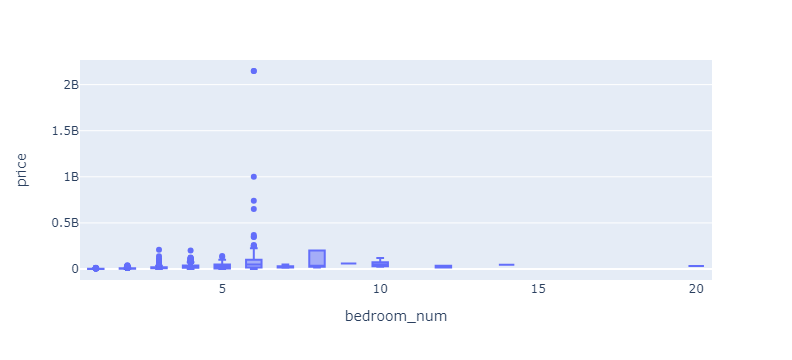

In [666]:
px.box(x='bedroom_num',y='price',data_frame=eda_data,hover_name=eda_data.index)

In [667]:
# 6193,4594,1737,4587

In [668]:
eda_data[eda_data.price>2000000000]

,property_type,city,bedroom_num,furnish,facing,age,class,price,value_label,total_landmark_count,balcony_num,area,feature_count,amenities_count,locality
2599,Residential Land,Hyderabad,6.0,unknown,East,0,A,2147483647,Freehold,2.0,0.0,7840800.0,0,0.0,Amangal
6193,Residential Land,Hyderabad,6.0,unknown,East,0,A,2147483647,Freehold,26.0,0.0,217800.0,0,0.0,Kokapet


In [669]:
new=eda_data.drop(index=[6193,4594,1737,4587,2599])

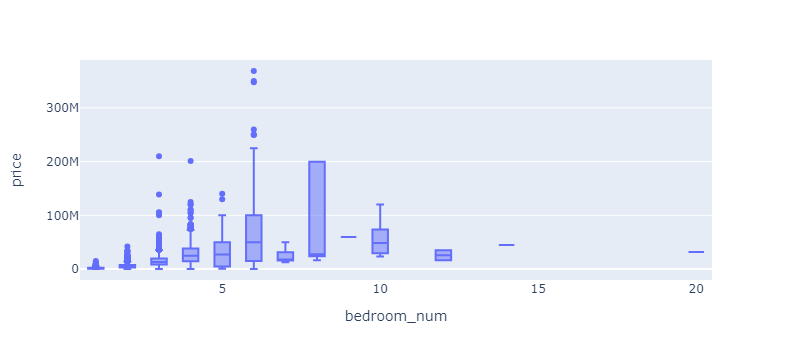

In [670]:
px.box(x='bedroom_num',y='price',data_frame=new,hover_name=new.index)

<AxesSubplot:xlabel='age', ylabel='price'>

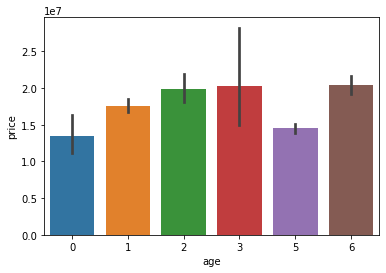

In [671]:
sns.barplot(x='age',y='price',data=eda_data)

<AxesSubplot:xlabel='total_landmark_count', ylabel='price'>

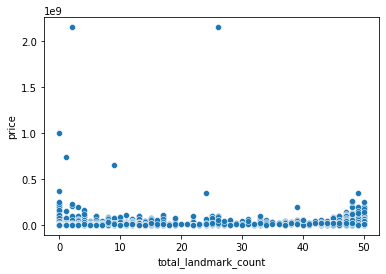

In [672]:
sns.scatterplot(x='total_landmark_count',y='price',data=eda_data)

<AxesSubplot:xlabel='balcony_num', ylabel='price'>

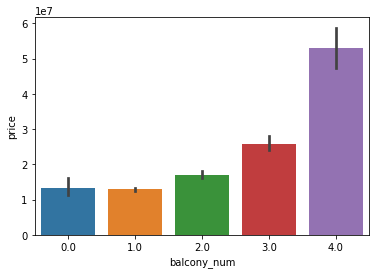

In [673]:
sns.barplot(x='balcony_num',y='price',data=eda_data)

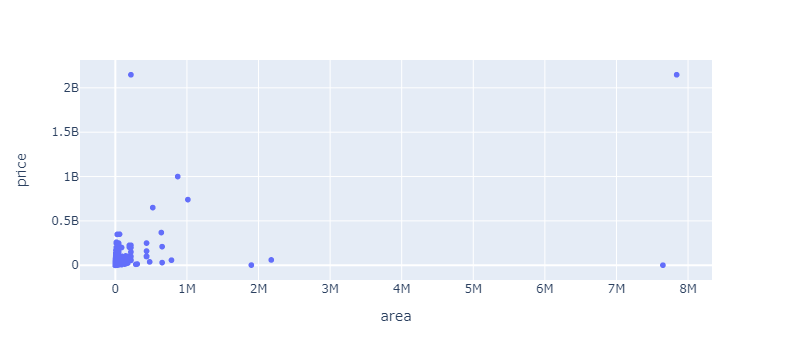

In [674]:
px.scatter(x='area',y='price',data_frame=eda_data,hover_name=eda_data.index)

In [675]:
#6193,2924,3796,2599,6874

In [676]:
# maybe drop land area higher than >700k
index_area=eda_data[eda_data.area>700000].index

In [677]:
drop_index=[6193,4587,1737, 2598, 2599, 2924, 3796, 4594, 6874]

In [678]:
model_data=model_data.drop(index=drop_index)

<AxesSubplot:xlabel='feature_count', ylabel='price'>

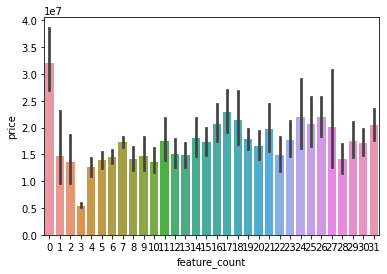

In [679]:
sns.barplot(x='feature_count',y='price',data=eda_data)

<AxesSubplot:xlabel='amenities_count', ylabel='price'>

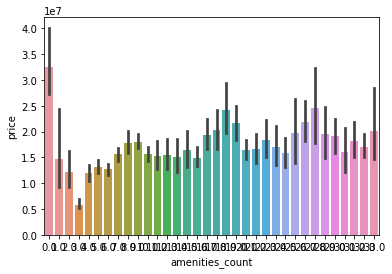

In [680]:
sns.barplot(x='amenities_count',y='price',data=eda_data)

<AxesSubplot:>

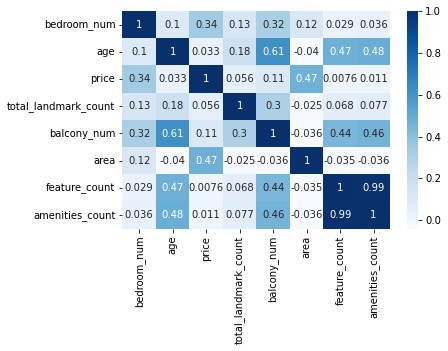

In [681]:
sns.heatmap(eda_data.corr(),annot=True,cmap='Blues')

In [682]:
# drop amenities_count

In [683]:
model_data.drop(columns='amenities_count',inplace=True)

In [684]:
eda_data=model_data.select_dtypes(include='object')

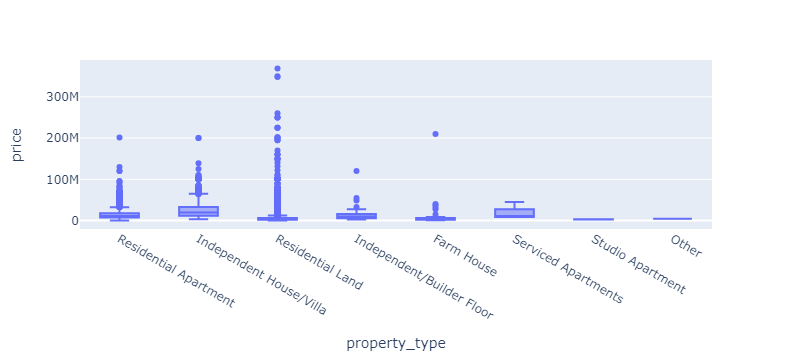

In [685]:
px.box(x='property_type',y='price',data_frame=model_data,hover_name=model_data.index)

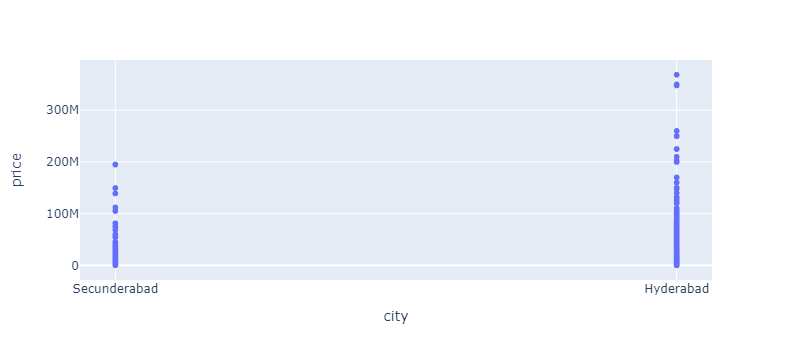

In [686]:
px.scatter(x='city',y='price',data_frame=model_data,hover_name=model_data.index)

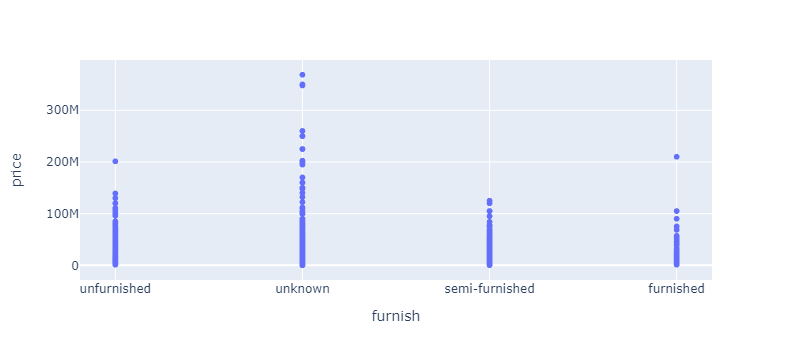

In [687]:
px.scatter(x='furnish',y='price',data_frame=model_data,hover_name=model_data.index)

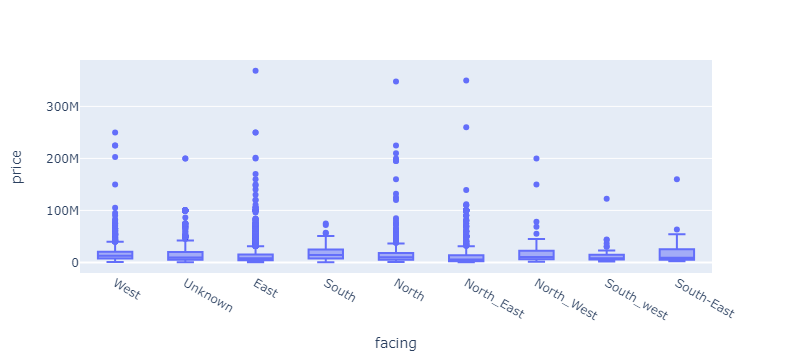

In [688]:
px.box(x='facing',y='price',data_frame=model_data,hover_name=model_data.index)

In [689]:
model_data.drop(columns='class',inplace=True) # calculated value not naturall collected

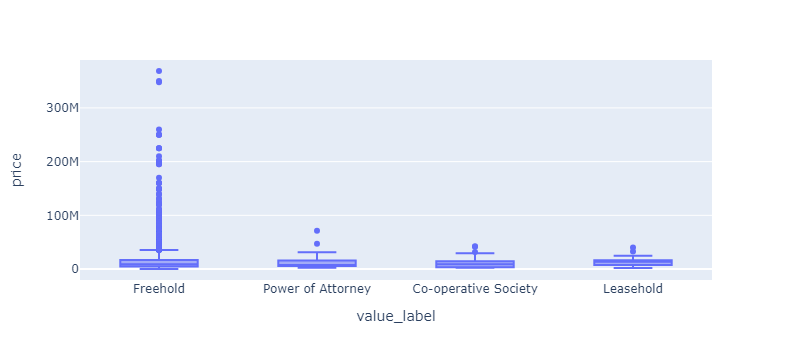

In [690]:
px.box(x='value_label',y='price',data_frame=model_data,hover_name=model_data.index)

In [692]:
model_data=model_data.reset_index(drop=True)

In [693]:
locality_filter=(model_data.locality.value_counts()*100/model_data.shape[0]).reset_index()

In [694]:
names=list(locality_filter.query('locality>=0.1')['index'])

In [695]:
model_data['new_locality']=model_data.locality.apply(lambda x : x if x in(names) else 'others')

###### Checking for anamolies among locality data

In [728]:
fig=px.scatter(y='price',x='area',data_frame=model_data,
               animation_frame='new_locality',range_x=[0,80000],range_y=[0,200000000],
               hover_name=model_data.index)

In [729]:
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 0.001

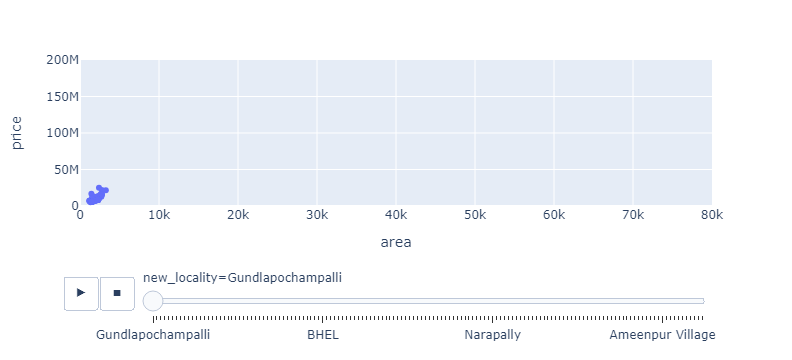

In [730]:
fig.show()

In [731]:
model_data['price_per_sqft']=model_data.price/model_data.area

In [732]:
# Removing outliers according to location
new,outliers=remove_outliers(model_data)

In [733]:
new.shape,outliers.shape

((6666, 16), (384, 16))

In [737]:
fig=px.scatter(y='area',x='price_per_sqft',data_frame=model_data,
               color='bedroom_num',range_y=[0,15000],
               animation_frame='new_locality',range_x=[0,80000],
               hover_name=model_data.index)

In [738]:
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 0.001

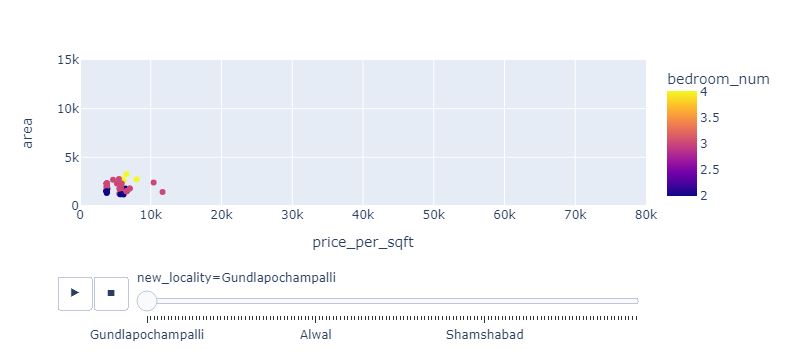

In [739]:
fig.show()

In [752]:
pred_data=model_data.copy()

In [753]:
pred_data.drop(columns='feature_count',inplace=True)

In [754]:
list(pred_data.select_dtypes(include='object').columns)

['property_type',
 'city',
 'furnish',
 'facing',
 'value_label',
 'locality',
 'new_locality']

In [755]:
pred_data.drop(columns='price_per_sqft',inplace=True)

In [756]:
pred_data=pred_data.reset_index(drop=True)

In [757]:
pred_data.property_type.unique()

array(['Residential Apartment', 'Independent House/Villa',
       'Residential Land', 'Independent/Builder Floor', 'Farm House',
       'Serviced Apartments', 'Studio Apartment', 'Other'], dtype=object)

In [758]:
pred_data.value_label.unique()

array(['Freehold', 'Power of Attorney', 'Co-operative Society',
       'Leasehold'], dtype=object)

In [759]:
pred_data.drop(columns='locality',inplace=True)

<AxesSubplot:>

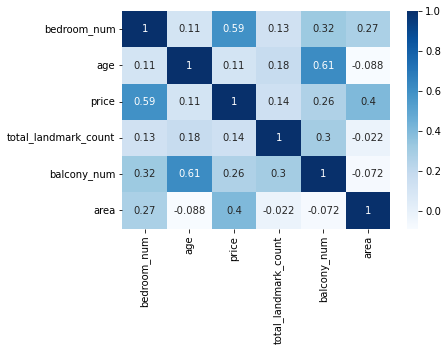

In [760]:
sns.heatmap(pred_data.corr(),annot=True,cmap='Blues')

In [770]:
# dropping Age because of very low correation to target variable
pred_data.drop(columns='age',inplace=True)

In [771]:
pred_data.shape

(7050, 11)

In [772]:
pred_data_1=pd.get_dummies(pred_data)

In [773]:
len(pred_data_1.columns)

172

In [774]:
scaler=MinMaxScaler()

In [775]:
ml_data=pred_data_1.copy()

### Model selection and hyper paramater tuning

In [776]:
# splitting for training and testing 
y=ml_data[['price']]
X=ml_data.drop(columns='price')

In [778]:
X[['bedroom_num','total_landmark_count','balcony_num','area']] = \
                   scaler.fit_transform(X.select_dtypes(include=['int64','float64']))

In [779]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=2)

In [780]:
X_train.shape,y_train.shape

((5640, 171), (5640, 1))

In [781]:
X_test.shape,y_test.shape

((1410, 171), (1410, 1))

##### Linear Model

In [115]:
linear_model=LinearRegression()

In [116]:
linear_model.fit(X_train,y_train)

LinearRegression()

In [117]:
linear_model.score(X_train,y_train)

0.4458238690223464

#### Random Forest Model

In [782]:
forest_model=RandomForestRegressor(random_state=73)

In [783]:
forest_model.fit(X_train,y_train.values.ravel())

RandomForestRegressor(random_state=73)

In [784]:
forest_model.score(X_train,y_train)

0.9420645524277673

In [797]:
y_pred=forest_model.predict(X_test)

In [798]:
mean_squared_error(y_test,y_pred)

80523880043109.83

In [799]:
extract=pd.DataFrame(list(X_train.columns),forest_model.feature_importances_).reset_index()

In [800]:
extract.rename(columns={0:'feature','index':'importance'},inplace=True)

In [801]:
plot_data=extract.sort_values('importance',ascending=False).head(10)

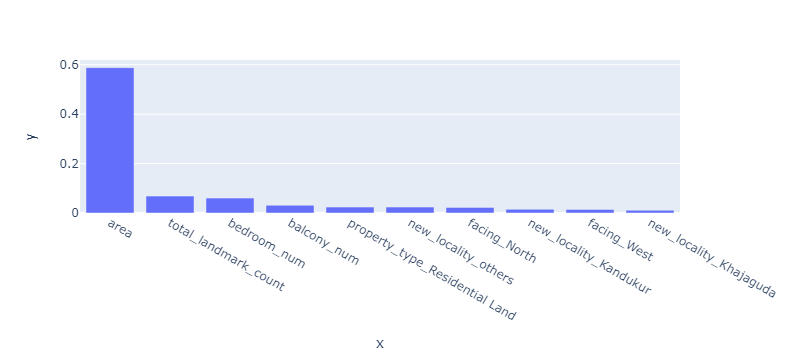

In [802]:
px.bar(x=plot_data.feature,y=plot_data.importance)

In [803]:
# hyper parameter tuning
forest_model.base_estimator_

DecisionTreeRegressor()

In [804]:
forest_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'mse',
 'max_depth': None,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_impurity_split': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 73,
 'verbose': 0,
 'warm_start': False}

#### Decision Tree Regressor